# Day 2 — Naive baselines + first scoreboard row

Establish the *you must beat me* floor. Three naive methods:

- **persistence-1**: y(t+24h) = y(t).
- **persistence-24**: y(t+24h) = y(t-24h+24h) = y(t). (Same as above — kept for clarity.)
- **same-hour-last-week**: y(t+24h) = y(t+24h - 168h). Captures hourly + weekly seasonality.

Honest expectation: same-hour-last-week is the only one of these that's competitive. The other two are sanity checks.

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from forecasting.data import load_demand
from forecasting.backtest import split_train_val_test
from forecasting.metrics import summarize

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.3f}'.format

## Load + split

In [2]:
df = load_demand('ERCO')
train, val, test = split_train_val_test(df)
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:5s} {len(part):>6,} rows  ({part.ts.min()} → {part.ts.max()})')

train 30,647 rows  (2020-01-01 00:00:00+00:00 → 2023-06-30 23:00:00+00:00)
val    4,416 rows  (2023-07-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00)
test   8,784 rows  (2024-01-01 00:00:00+00:00 → 2024-12-31 23:00:00+00:00)


/Users/visethsean/Documents/ercot-demand-forecast/forecasting/data.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn, params=(region,))


## Baselines

Task: predict demand at time `t+24h` given everything observed up to time `t`.

We build prediction tables aligned to the test set. Note: each baseline uses ONLY values from before its prediction time — no leakage.

In [3]:
# Use the full history (train + val + test) as a lookup table — prediction at t reads
# values from BEFORE t only, so this is still leakage-free.
history = pd.concat([train, val, test]).sort_values('ts').reset_index(drop=True)
history = history.set_index('ts')['demand_mwh']

# Predict for each timestamp in the test set
test_idx = test['ts']
y_true = test['demand_mwh'].to_numpy()

# Persistence: same value 24h before the prediction target
y_pred_persist = history.reindex(test_idx - pd.Timedelta('24h')).to_numpy()

# Same-hour-last-week
y_pred_week = history.reindex(test_idx - pd.Timedelta('168h')).to_numpy()

# Naive seasonal average — mean of past 4 weeks at same hour-of-week
y_pred_4week = np.mean([
    history.reindex(test_idx - pd.Timedelta(f'{168 * k}h')).to_numpy()
    for k in (1, 2, 3, 4)
], axis=0)

# Drop any NaN rows (from the very early test set where 4-week lookback is missing)
mask = ~(np.isnan(y_pred_persist) | np.isnan(y_pred_week) | np.isnan(y_pred_4week))
print(f'Evaluating on {mask.sum():,} of {len(y_true):,} test points (drops {(~mask).sum()} early-test rows)')

y_true_m       = y_true[mask]
preds = {
    'persistence-24h':         y_pred_persist[mask],
    'same-hour-last-week':     y_pred_week[mask],
    'avg-same-hour-last-4-wk': y_pred_4week[mask],
}

Evaluating on 8,784 of 8,784 test points (drops 0 early-test rows)


## Scoreboard

In [4]:
scoreboard = {name: summarize(y_true_m, p) for name, p in preds.items()}
score_df = pd.DataFrame(scoreboard).T
score_df['mape_pct'] = score_df['mape'] * 100
score_df = score_df[['mape_pct', 'rmse', 'mae']]
score_df

,mape_pct,rmse,mae
persistence-24h,4.504,"3,399.633","2,351.624"
same-hour-last-week,8.352,"6,271.513","4,480.933"
avg-same-hour-last-4-wk,8.888,"6,247.948","4,777.281"


## Save scoreboard row

In [5]:
out = Path('..') / 'results' / 'scoreboard.json'
out.parent.mkdir(exist_ok=True)

payload = {
    'test_range': [str(test.ts.min()), str(test.ts.max())],
    'n_eval_points': int(mask.sum()),
    'results': {
        name: {k: float(v) for k, v in metrics.items()}
        for name, metrics in scoreboard.items()
    },
}
out.write_text(json.dumps(payload, indent=2))
print(f'Wrote {out}')
print(json.dumps(payload, indent=2)[:500] + '...')

Wrote ../results/scoreboard.json
{
  "test_range": [
    "2024-01-01 00:00:00+00:00",
    "2024-12-31 23:00:00+00:00"
  ],
  "n_eval_points": 8784,
  "results": {
    "persistence-24h": {
      "mape": 0.04503756968956085,
      "rmse": 3399.633331676399,
      "mae": 2351.624089253188
    },
    "same-hour-last-week": {
      "mape": 0.08352045194806491,
      "rmse": 6271.512593659658,
      "mae": 4480.932604735884
    },
    "avg-same-hour-last-4-wk": {
      "mape": 0.08887946270541235,
      "rmse": 6247.948011309962,
   ...


## Visualize one week

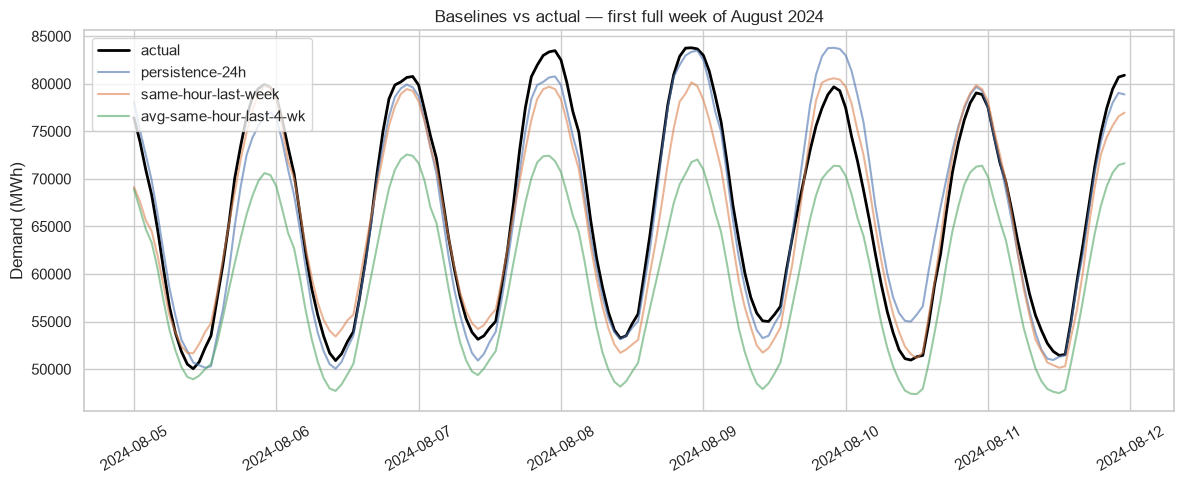

In [6]:
# Plot a sample week from the test set
test_with_preds = test.copy().iloc[mask].reset_index(drop=True)
for name, p in preds.items():
    test_with_preds[name] = p

# Pick a representative week — first full week of August 2024 (summer)
wk = test_with_preds[(test_with_preds.ts >= '2024-08-05') & (test_with_preds.ts < '2024-08-12')]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wk.ts, wk.demand_mwh, label='actual', color='black', lw=2)
for name in preds:
    ax.plot(wk.ts, wk[name], label=name, alpha=0.6)
ax.legend()
ax.set_title('Baselines vs actual — first full week of August 2024')
ax.set_ylabel('Demand (MWh)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Takeaways for Day 3

**Surprise finding: persistence-24h beat same-hour-last-week** (MAPE 4.5% vs 8.4%).

Going in, intuition said weekly seasonality should win — same-hour-last-week gets both the right hour AND the right day-of-week. The data said otherwise. Persistence-24h trades the day-of-week alignment for much fresher weather context, and weather drives most demand variance in Texas. A week of weather drift outweighs the day-of-week boost.

Other notes:
- The averaging baseline (`avg-same-hour-last-4-wk`) smooths anomalies but doesn't help here.
- LightGBM on Day 3 has a clear bar to clear: beat **persistence-24h at MAPE 4.5%** by a meaningful margin.
- Calibrated prediction intervals come in Day 3+ via quantile LightGBM.

**Lesson: domain intuition is a hypothesis to test, not a fact.**